<a href="https://colab.research.google.com/github/nyary-ben/Homework-7A/blob/main/Homework_7A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install whit-phys-util 1>/dev/null

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import whit_phys_util as buc
from numpy import pi, exp, sqrt
from scipy.integrate import quad
from scipy.optimize import root_scalar
import warnings

In [30]:
repo = buc.local_repository("https://github.com/nyary-ben/Homework-7A")

Repository exists at this location. Pulling changes from GitHub.


## Problem 7.2 b
* The probability for Myoglobin to be occupied by $O_2$ molecules,
$$Prob(O_2) = \frac{1}{1+\frac{a}{P_{O_2}}}$$ where $a$ = $ce^{\epsilon \beta}$.
* The probability for the simplified Hemoglobin to be occupied by $O_2$ molecules,
$$Prob_2(O_2) = \frac{1}{1+\frac{c(2e^{\epsilon_2\beta}+e^{\epsilon_3\beta})}{P_{O_2}}}$$ where $c$ = $\frac{kTZ_eZ_{rot}}{V_Q}$.

In [24]:

c = (1.77*10**14)/100000 #Pa
T = 310 #K
keV = 8.617*10**-5 #eV/K
betev = 1/(keV*T)

en1 = -0.7 #eV (the energy of state 1 in Myoglobin)
ep1 = en1*betev

en2 = -0.55 #eV (the energy of state 2 in Hemoglobin)
en3 = -1.3 #eV (the energy of state 3 in Hemoglobin)
ep2 = en2*betev
ep3 = en3*betev

amyo = c*exp(ep1)
ahem = c*((2*exp(ep2))+exp(ep3))

def Prob(a,Po):
    return 1/(1+(a/Po))
ahem


np.float64(4.046835084549532)

Text(0, 0.5, 'Probability')

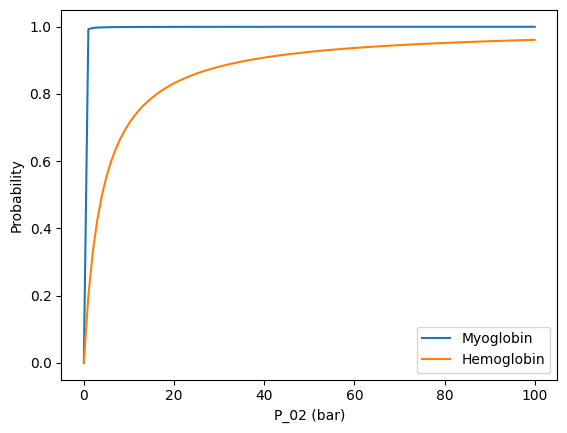

In [25]:
P = np.linspace(1e-9, 100, 100)

fig, ax1 = plt.subplots()
ax1.plot(P, Prob(amyo,P), label = 'Myoglobin')
ax1.plot(P, Prob(ahem,P), label = 'Hemoglobin')
ax1.legend()
ax1.set_xlabel('P_02 (bar)')
ax1.set_ylabel('Probability')


## Problem 7.16 b
The probability of each energy level is the multiplicity of one energy level over the multiplicity over all mulitiplicities found from the dot diagram.

In [27]:
data = {'q': [0, 1, 2, 3, 4, 5, 6], 'Probability': [1/37, 1/37, 2/37, 3/37, 6/37, 10/37, 14/37]}
df = pd.DataFrame(data)

Text(0, 0.5, 'Probability')

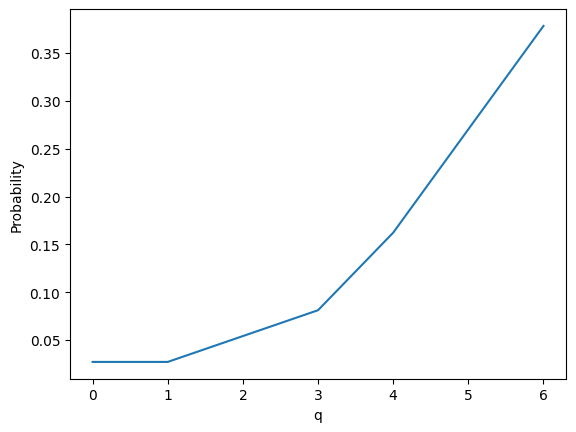

In [28]:
fig, ax3 = plt.subplots()
ax3.plot(df['q'], df['Probability'])
ax3.set_xlabel('q')
ax3.set_ylabel('Probability')

### 7.16 c
The Fermi-dirac distribution is going to be the probability;
$$\bar n = \frac{1}{e^{(\epsilon-\mu)/kT}+1}$$

In [56]:
#E = epsi - mu
E = 6 # hypothetical
k = 8.617*10**-5 #eV/K
def FindP(E,T1):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore",category=RuntimeWarning)
  return 1/(1+exp((E)/k*T1))

def FindT(E):
  sol = root_scalar(lambda T6: FindP(E,T6)-(14/37), bracket=(0,1))
  return sol.root

In [58]:
T6 = FindT(E)
print(f"At T = {T6} K")

At T = 7.129661083269895e-06 K


<ipython-input-56-f4818b0d65fe>:7: RuntimeWarning: overflow encountered in exp
  return 1/(1+exp((E)/k*T1))
<ipython-input-56-f4818b0d65fe>:7: RuntimeWarning: overflow encountered in exp
  return 1/(1+exp((E)/k*T1))
<ipython-input-56-f4818b0d65fe>:7: RuntimeWarning: overflow encountered in exp
  return 1/(1+exp((E)/k*T1))
<ipython-input-56-f4818b0d65fe>:7: RuntimeWarning: overflow encountered in exp
  return 1/(1+exp((E)/k*T1))


After rearranging the formula having found $T$ = $7.12 \times 10^-6 K$, we found $\mu$ = $kTln(\bar n) +\epsilon$.

In [61]:
mu = (np.log(14/37)*k*T6)+1 #epsilon  = 1 eV as there is equally one energy unit per energy level
print(f"At mu = {mu} eV")

At mu = 0.9999999994029249 
